# Análisis Exploratorio de Datos
## Demanda energética en Colombia 2024–2025
---
Este documento contiene el análisis exploratorio de datos del consumo energético eléctrico en Colombia, extraído del portal SIMEM de XM para el período 2024–2025.

## 1. Carga de datos
---
Los datos fueron extraídos del portal [SIMEM](https://www.simem.co/) de XM, empresa encargada de la operación del Sistema Interconectado Nacional (SIN). El dataset está disponible en Google Drive.

In [1]:
!pip install gdown

In [2]:
!gdown --id 17xBCKcwhDvzE-JVxBS2h3C6pAFXrKtnE -O demanda_colombia.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17xBCKcwhDvzE-JVxBS2h3C6pAFXrKtnE
From (redirected): https://drive.google.com/uc?id=17xBCKcwhDvzE-JVxBS2h3C6pAFXrKtnE&confirm=t&uuid=a438fb26-a28d-4f94-a01c-ed06c1b4d8db
To: /content/demanda_colombia.csv
100% 285M/285M [00:01<00:00, 146MB/s]


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

demanda_colombia = pd.read_csv('demanda_colombia.csv')

## 2. Estructura del dataset
---
El dataset contiene registros horarios de demanda real de energía por agente del mercado eléctrico colombiano.

| # | Columna | Tipo | Descripción |
|---|---------|------|-------------|
| 1 | `CodigoVariable` | `string` | Código de la variable medida. Toma un único valor: `DdaReal`, correspondiente a demanda real |
| 2 | `FechaHora` | `datetime` | Marca de tiempo del registro en formato `YYYY-MM-DD HH:MM:SS`. Representa cada hora del período consultado |
| 3 | `CodigoSICAgente` | `string` | Código único del agente registrado en el Sistema de Información Comercial (SIC). Identifica la empresa distribuidora u operador de red. [Ver agentes](https://www.xm.com.co/transacciones/registros/registro-agentes-y-contactos/estructura-del-mercado) |
| 4 | `TipoMercado` | `string` | Segmento del mercado al que pertenece el agente. **Regulado**: consumo de hogares, comercio y pequeños consumidores. **No regulado**: grandes consumidores industriales que negocian contratos directamente |
| 5 | `Version` | `string` | Versión del dato publicado. XM emite revisiones del mismo período: TX1 es el dato más preliminar, TX2 una mejor estimación, y TXF el dato definitivo (puede demorar hasta un año) |
| 6 | `Valor` | `float` | **Variable objetivo.** Consumo de energía eléctrica expresado en **kWh** |
| 7 | `UnidadMedida` | `string` | Unidad de medida del campo `Valor`. Toma un único valor: **kWh** |
| 8 | `CodigoDuracion` | `string` | Granularidad temporal del registro. Correspondiente a medición **horaria** (PT1H) |

In [4]:
print(f'Observaciones: {demanda_colombia.shape[0]}')
print(f'Variables:     {demanda_colombia.shape[1]}')
demanda_colombia.info()

Observaciones: 4450032
Variables:     8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4450032 entries, 0 to 4450031
Data columns (total 8 columns):
 #   Column           Dtype  
---  ------           -----  
 0   CodigoVariable   object 
 1   FechaHora        object 
 2   CodigoSICAgente  object 
 3   TipoMercado      object 
 4   Version          object 
 5   Valor            float64
 6   UnidadMedida     object 
 7   CodigoDuracion   object 
dtypes: float64(1), object(7)
memory usage: 271.6+ MB


## 3. Calidad general de los datos
---

### Valores faltantes

In [5]:
resumen_calidad = pd.DataFrame({
    'Tipo': demanda_colombia.dtypes,
    'No nulos': demanda_colombia.count(),
    'Nulos': demanda_colombia.isnull().sum(),
    '% Nulos': (demanda_colombia.isnull().mean() * 100).round(2),
    'Únicos': demanda_colombia.nunique()
})
print(resumen_calidad)

                    Tipo  No nulos  Nulos  % Nulos   Únicos
CodigoVariable    object   4450032      0      0.0        1
FechaHora         object   4450032      0      0.0    17544
CodigoSICAgente   object   4450032      0      0.0       67
TipoMercado       object   4450032      0      0.0        2
Version           object   4450032      0      0.0        9
Valor            float64   4450032      0      0.0  1964762
UnidadMedida      object   4450032      0      0.0        1
CodigoDuracion    object   4450032      0      0.0        1


### Duplicados

In [6]:
duplicados = demanda_colombia.duplicated().sum()
print(f'Duplicados: {duplicados} ({duplicados/len(demanda_colombia)*100:.2f}%)')

Duplicados: 0 (0.00%)


### Valores negativos en variable numérica

In [7]:
negativos = (demanda_colombia['Valor'] < 0).sum()
print(f'Valores negativos en Valor: {negativos} ({negativos/len(demanda_colombia)*100:.2f}%)')

Valores negativos en Valor: 0 (0.00%)


## 4. Análisis por variable
---

### 4.1 CodigoVariable
Esta columna toma un único valor (`DdaReal`) para la totalidad de los datos, por lo tanto no aporta información y se descarta.

In [8]:
demanda_colombia_subset = demanda_colombia.drop(columns='CodigoVariable')

### 4.2 FechaHora

In [9]:
a = len(demanda_colombia_subset['FechaHora'].unique())
b = len(demanda_colombia_subset)
print(f'Fechas únicas: {a} sobre {b} registros totales')
print('Por una misma fecha pueden existir múltiples agentes y versiones.')

Fechas únicas: 17544 sobre 4450032 registros totales
Por una misma fecha pueden existir múltiples agentes y versiones.


In [10]:
# Verificación de formato
import re
patron_fecha = r'^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}$'
fechas = demanda_colombia_subset['FechaHora']
cumple_formato = fechas.str.match(patron_fecha)

if cumple_formato.all():
    print('Todas las fechas cumplen el formato YYYY-MM-DDTHH:MM:SS')
else:
    print('Fechas que no cumplen el formato:')
    display(fechas[~cumple_formato])

Todas las fechas cumplen el formato YYYY-MM-DDTHH:MM:SS


In [11]:
demanda_colombia_subset['FechaHora'] = pd.to_datetime(demanda_colombia_subset['FechaHora'])

**Distribución de registros por mes**

Se observa un aumento abrupto de registros entre diciembre 2024 y enero 2025. Esto se explica por las versiones del dato: en 2024 predominan versiones tardías de reconciliación (TX4–TX8), mientras que en 2025 coexisten versiones preliminares (TXR) y finales (TXF), lo que multiplica el volumen de registros.

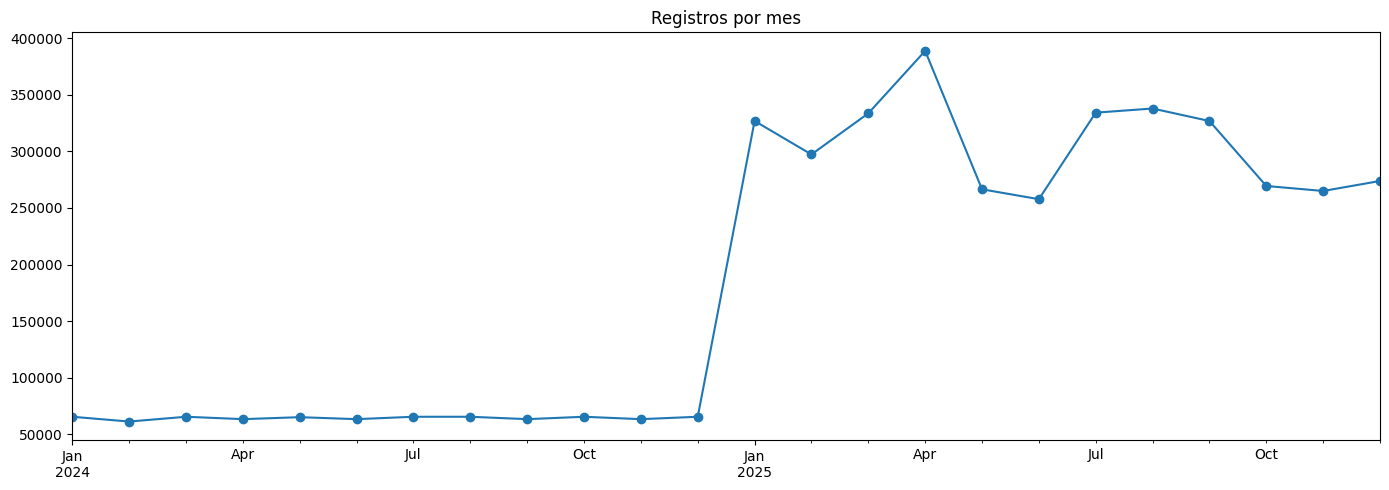

In [12]:
registros_mes = demanda_colombia_subset.resample('ME', on='FechaHora').size()

registros_mes.plot(figsize=(14, 5),
                   title='Registros por mes',
                   xlabel='',
                   marker='o')
plt.tight_layout()
plt.show()

### 4.3 CodigoSICAgente

In [13]:
agentes = demanda_colombia_subset['CodigoSICAgente']
print(f'Agentes únicos: {agentes.nunique()}')
print(f'Valores nulos: {agentes.isna().sum()}')
print(f'Agentes sin espacios en blanco: {agentes.str.strip().nunique()}')

Agentes únicos: 67
Valores nulos: 0
Agentes sin espacios en blanco: 67


**Distribución de registros por agente**

La curva de Pareto muestra un comportamiento casi lineal, lo que indica que los registros están distribuidos de forma equilibrada entre agentes, significa que ninguno domina el dataset. El 60% de los registros se concentran en los primeros 28 agentes.

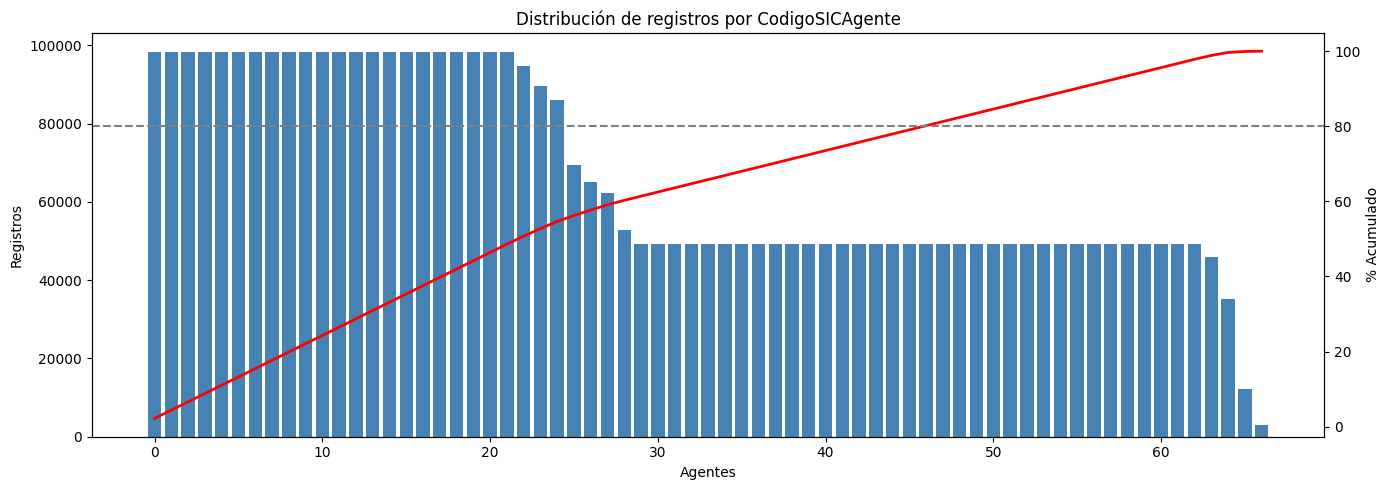

In [14]:
conteo = demanda_colombia_subset['CodigoSICAgente'].value_counts()
acumulado = conteo.cumsum() / conteo.sum() * 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(range(len(conteo)), conteo.values, color='steelblue')
ax1.set_ylabel('Registros')
ax1.set_xlabel('Agentes')

ax2 = ax1.twinx()
ax2.plot(range(len(conteo)), acumulado.values, color='red', linewidth=2)
ax2.axhline(80, color='gray', linestyle='--', label='80%')
ax2.set_ylabel('% Acumulado')

plt.title('Distribución de registros por CodigoSICAgente')
plt.tight_layout()
plt.show()

### 4.4 TipoMercado

In [15]:
print(f'Valores nulos: {demanda_colombia_subset["TipoMercado"].isna().sum()}')
demanda_colombia_subset['TipoMercado'].value_counts()

Valores nulos: 0


,count
TipoMercado,
No Regulado,2233944
Regulado,2216088


### 4.5 Version

XM publica múltiples versiones del mismo dato a medida que avanza el proceso de liquidación del mercado. Esto explica directamente el salto de registros observado entre 2024 y 2025: los datos de 2024 solo contienen versiones tardías de reconciliación (TX4–TX8), mientras que los de 2025 incluyen versiones preliminares y finales.

In [16]:
demanda_colombia_subset['Version'].value_counts()

,count
Version,
TXR,798384
TXF,798384
TX2,754704
TX4,728760
TX3,594528
TX5,390888
TX7,194304
TX6,126720
TX8,63360


In [17]:
# Versiones por año
demanda_colombia_subset.groupby(
    [demanda_colombia_subset['FechaHora'].dt.year, 'Version']
).size().unstack(fill_value=0)

Version,TX2,TX3,TX4,TX5,TX6,TX7,TX8,TXF,TXR
FechaHora,,,,,,,,,
2024,0,0,130584,257664,126720,194304,63360,0,0
2025,754704,594528,598176,133224,0,0,0,798384,798384


In [18]:
versiones_2024 = set(demanda_colombia_subset[demanda_colombia_subset['FechaHora'].dt.year == 2024]['Version'])
versiones_2025 = set(demanda_colombia_subset[demanda_colombia_subset['FechaHora'].dt.year == 2025]['Version'])

print(f'Versiones 2024:  {versiones_2024}')
print(f'Versiones 2025:  {versiones_2025}')
print(f'En común:        {versiones_2024 & versiones_2025}')
print(f'Solo en 2024:    {versiones_2024 - versiones_2025}')
print(f'Solo en 2025:    {versiones_2025 - versiones_2024}')

Versiones 2024:  {'TX4', 'TX8', 'TX6', 'TX5', 'TX7'}
Versiones 2025:  {'TXF', 'TX2', 'TX4', 'TX5', 'TX3', 'TXR'}
En común:        {'TX5', 'TX4'}
Solo en 2024:    {'TX8', 'TX6', 'TX7'}
Solo en 2025:    {'TXR', 'TXF', 'TX2', 'TX3'}


### 4.6 Valor

**Variable objetivo:** consumo de energía eléctrica en kWh.

In [19]:
print(f'Valores nulos: {demanda_colombia_subset["Valor"].isna().sum()}')
demanda_colombia_subset['Valor'].describe()

Valores nulos: 0


,Valor
count,4.450032e+06
mean,1.048312e+05
std,2.339283e+05
min,0.000000e+00
25%,1.859277e+03
50%,1.650694e+04
75%,8.023762e+04
max,1.682582e+06


**Valores en cero**

Se identificaron registros con valor 0. El análisis muestra que se concentran en 3 agentes del mercado No Regulado (GSAC, BCCC, TRPC), distribuidos uniformemente a lo largo de todas las horas del día, lo que sugiere que corresponden a registros sin medición y no a inactividad real. Dado que representan solo el 3% de los datos, se decide eliminarlos del estudio.

In [20]:
ceros = demanda_colombia_subset[demanda_colombia_subset['Valor'] == 0]
print(f'Registros en cero: {len(ceros)} ({len(ceros)/len(demanda_colombia_subset)*100:.1f}%)')
print()
print('Por TipoMercado:')
print(ceros['TipoMercado'].value_counts())
print()
print('Por agente (top 5):')
print(ceros.groupby('CodigoSICAgente').size().sort_values(ascending=False).head())

Registros en cero: 129813 (2.9%)

Por TipoMercado:
TipoMercado
No Regulado    119040
Regulado        10773
Name: count, dtype: int64

Por agente (top 5):
CodigoSICAgente
GSAC    40822
BCCC    34236
TRPC    33024
SCEC     7888
RPEC     6459
dtype: int64


In [21]:
index_ceros = demanda_colombia_subset[demanda_colombia_subset['Valor'] == 0].index
demanda_colombia_subset_noCeros = demanda_colombia_subset.drop(index_ceros)
print(f'Registros tras eliminar ceros: {len(demanda_colombia_subset_noCeros)}')

Registros tras eliminar ceros: 4320219


### 4.7 Columnas sin valor analítico

`UnidadMedida`, `CodigoDuracion` y `SistemaTransmision` toman un único valor en todo el dataset, por lo tanto no aportan información al modelo y se descartan.

In [22]:
final_demanda_colombia = demanda_colombia_subset_noCeros.drop(
    columns=['CodigoDuracion', 'UnidadMedida']
)
print(f'Columnas finales: {list(final_demanda_colombia.columns)}')

Columnas finales: ['FechaHora', 'CodigoSICAgente', 'TipoMercado', 'Version', 'Valor']


## 5. Variable objetivo
---
En esta sección se describe el comportamiento de la variable `Valor` — consumo de energía eléctrica en kWh.

### Distribución

La distribución presenta asimetría positiva (sesgo a la derecha), lo cual es característico de variables de consumo energético donde la mayoría de agentes tienen consumos moderados pero existen algunos con valores muy altos.

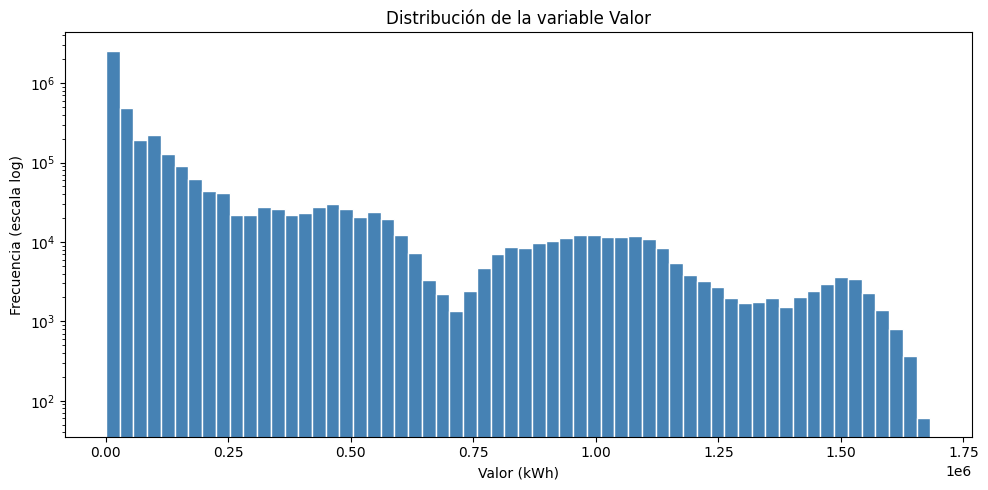

In [28]:
plt.figure(figsize=(10, 5))
plt.hist(final_demanda_colombia['Valor'], bins=60, color='steelblue', edgecolor='white')
plt.yscale('log')
plt.title("Distribución de la variable Valor")
plt.xlabel("Valor (kWh)")
plt.ylabel("Frecuencia (escala log)")
plt.tight_layout()
plt.show()

## 6. Relación entre variables temporales y demanda
---
A partir de `FechaHora` se extraen variables temporales para analizar su relación con el consumo energético.

In [25]:
final_demanda_colombia = final_demanda_colombia.copy()
final_demanda_colombia['hora'] = final_demanda_colombia['FechaHora'].dt.hour
final_demanda_colombia['dia_semana'] = final_demanda_colombia['FechaHora'].dt.dayofweek
final_demanda_colombia['mes'] = final_demanda_colombia['FechaHora'].dt.month

### Demanda por hora, día y mes

Se observa que la hora del día presenta la mayor influencia, seguida del mes y el día de la semana — consistente con los ciclos de consumo energético.

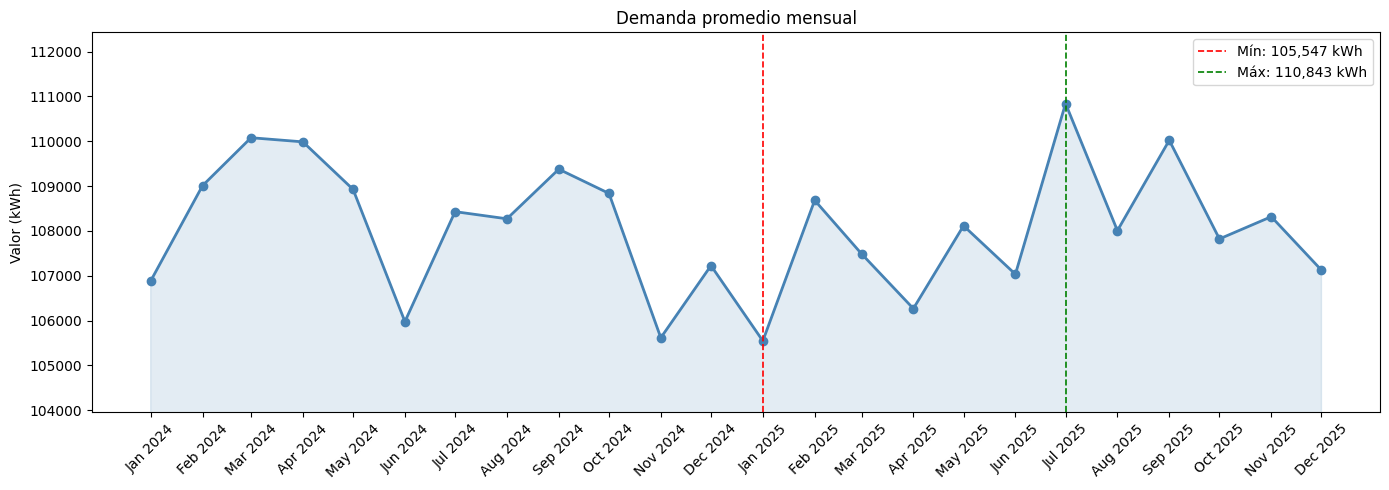

In [43]:
df_mensual = final_demanda_colombia.groupby(
    final_demanda_colombia['FechaHora'].dt.to_period('M')
)['Valor'].mean()

df_mensual.index = df_mensual.index.to_timestamp()

mes_min = df_mensual.idxmin()
mes_max = df_mensual.idxmax()

plt.figure(figsize=(14, 5))
plt.plot(df_mensual, marker='o', linewidth=2, color='steelblue')
plt.fill_between(df_mensual.index, df_mensual.values, alpha=0.15, color='steelblue')


plt.axvline(mes_min, color='red', linestyle='--', linewidth=1.2,
            label=f'Mín: {df_mensual.min():,.0f} kWh')
plt.axvline(mes_max, color='green', linestyle='--', linewidth=1.2,
            label=f'Máx: {df_mensual.max():,.0f} kWh')
plt.legend()

plt.title('Demanda promedio mensual')
plt.ylabel('Valor (kWh)')

margen = (df_mensual.max() - df_mensual.min()) * 0.3
plt.ylim(df_mensual.min() - margen, df_mensual.max() + margen)

plt.xticks(df_mensual.index,
           [d.strftime('%b %Y') for d in df_mensual.index],
           rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_363/3376264756.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(dias)


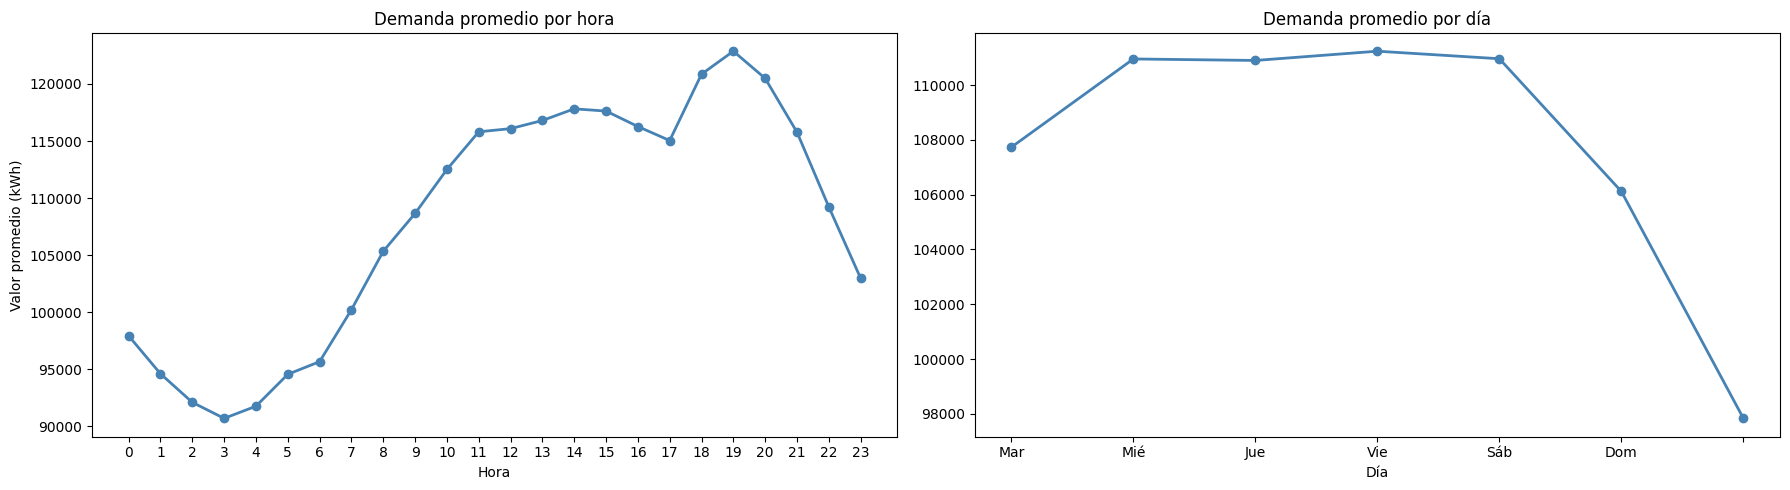

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Por hora
final_demanda_colombia.groupby('hora')['Valor'].mean().plot(
    ax=axes[0], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Demanda promedio por hora')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Valor promedio (kWh)')
axes[0].set_xticks(range(0, 24))

# Por día de semana
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
final_demanda_colombia.groupby('dia_semana')['Valor'].mean().plot(
    ax=axes[1], marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Demanda promedio por día')
axes[1].set_xlabel('Día')
axes[1].set_xticklabels(dias)


plt.tight_layout()
plt.show()

Los patrones temporales confirman que la demanda energética está fuertemente influenciada por ciclos horarios, semanales y estacionales. Esto valida el uso de variables derivadas de `FechaHora` como features relevantes para el modelo predictivo.